<a href="https://colab.research.google.com/github/marsyaaurel08/Machine_Learning_Ganjil25_15/blob/main/JS13_ANN_MARSYA_AURELIA_S.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM 1

In [ ]:
import numpy as np

# Dataset XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Parameter
input_size = 2
hidden_size = 2
output_size = 1
lr = 0.1

# Inisialisasi bobot
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

# Fungsi aktivasi
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Training
for epoch in range(10000):
    # Forward pass
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    # Hitung error
    error = y - a2

    # Backpropagation
    d_a2 = error * sigmoid_derivative(a2)
    d_W2 = np.dot(a1.T, d_a2)
    d_b2 = np.sum(d_a2, axis=0, keepdims=True)

    d_a1 = np.dot(d_a2, W2.T) * sigmoid_derivative(a1)
    d_W1 = np.dot(X.T, d_a1)
    d_b1 = np.sum(d_a1, axis=0, keepdims=True)

    # Update bobot
    W1 += lr * d_W1
    b1 += lr * d_b1
    W2 += lr * d_W2
    b2 += lr * d_b2

    if epoch % 1000 == 0:
        loss = np.mean(np.square(error))
        print(f"Epoch {epoch}, Loss: {loss}")

# Output akhir
print("Prediksi:")
print(a2)

Epoch 0, Loss: 0.3007081039016162
Epoch 1000, Loss: 0.22214656999055343
Epoch 2000, Loss: 0.162443050961797
Epoch 3000, Loss: 0.1414552378177779
Epoch 4000, Loss: 0.13474241596703943
Epoch 5000, Loss: 0.13175215869195417
Epoch 6000, Loss: 0.13011124297739363
Epoch 7000, Loss: 0.12908833112182205
Epoch 8000, Loss: 0.1283946598554026
Epoch 9000, Loss: 0.12789551500602203
Prediksi:
[[0.04627872]
 [0.95745326]
 [0.49637136]
 [0.50248232]]


# TUGAS 1

In [1]:
# Mengubah jumlah neuron hidden layer menjadi 3
# Bandingkan hasil loss dengan konfigurasi awal
import numpy as np

# Dataset XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Parameter
input_size = 2
hidden_size = 3   # <<-- diubah dari 2 menjadi 3
output_size = 1
lr = 0.1

# Inisialisasi bobot
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

# Fungsi aktivasi sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Training
for epoch in range(10000):
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    error = y - a2

    d_a2 = error * sigmoid_derivative(a2)
    d_W2 = np.dot(a1.T, d_a2)
    d_b2 = np.sum(d_a2, axis=0, keepdims=True)

    d_a1 = np.dot(d_a2, W2.T) * sigmoid_derivative(a1)
    d_W1 = np.dot(X.T, d_a1)
    d_b1 = np.sum(d_a1, axis=0, keepdims=True)

    W1 += lr * d_W1
    b1 += lr * d_b1
    W2 += lr * d_W2
    b2 += lr * d_b2

    if epoch % 1000 == 0:
        loss = np.mean(np.square(error))
        print(f"Epoch {epoch}, Loss: {loss}")

print("Prediksi (sigmoid, hidden=3):")
print(a2)


Epoch 0, Loss: 0.28553957288410053
Epoch 1000, Loss: 0.24924387582445007
Epoch 2000, Loss: 0.24472337878005412
Epoch 3000, Loss: 0.17936092284007474
Epoch 4000, Loss: 0.03693245744310263
Epoch 5000, Loss: 0.013287852854511405
Epoch 6000, Loss: 0.007476267945845319
Epoch 7000, Loss: 0.005068780116397858
Epoch 8000, Loss: 0.0037895280706481847
Epoch 9000, Loss: 0.0030066274396464226
Prediksi (sigmoid, hidden=3):
[[0.05080461]
 [0.94280112]
 [0.95378794]
 [0.04406661]]


In [2]:
# Menambahkan fungsi aktivasi ReLU dan membandingkan hasilnya
import numpy as np

# Dataset XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Parameter
input_size = 2
hidden_size = 3
output_size = 1
lr = 0.1

# Inisialisasi bobot
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

# ReLU + sigmoid output
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Training
for epoch in range(10000):
    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)  # <<-- aktivasi diganti ReLU
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    error = y - a2

    d_a2 = error * sigmoid_derivative(a2)
    d_W2 = np.dot(a1.T, d_a2)
    d_b2 = np.sum(d_a2, axis=0, keepdims=True)

    d_a1 = np.dot(d_a2, W2.T) * relu_derivative(z1)  # <<-- turunan ReLU
    d_W1 = np.dot(X.T, d_a1)
    d_b1 = np.sum(d_a1, axis=0, keepdims=True)

    W1 += lr * d_W1
    b1 += lr * d_b1
    W2 += lr * d_W2
    b2 += lr * d_b2

    if epoch % 1000 == 0:
        loss = np.mean(np.square(error))
        print(f"Epoch {epoch}, Loss: {loss}")

print("Prediksi (ReLU, hidden=3):")
print(a2)


Epoch 0, Loss: 0.3019934512263372
Epoch 1000, Loss: 0.2500000000027674
Epoch 2000, Loss: 0.25
Epoch 3000, Loss: 0.25
Epoch 4000, Loss: 0.25
Epoch 5000, Loss: 0.25
Epoch 6000, Loss: 0.25
Epoch 7000, Loss: 0.25
Epoch 8000, Loss: 0.25
Epoch 9000, Loss: 0.25
Prediksi (ReLU, hidden=3):
[[0.5]
 [0.5]
 [0.5]
 [0.5]]


**Visualisasi Perbandingan**

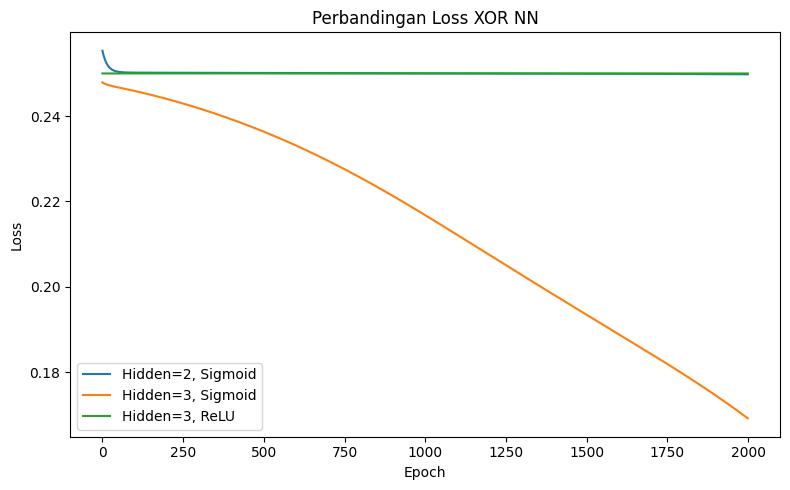

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_der(x):
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

def relu_der(x):
    return (x > 0).astype(float)

# Training function
def train(hidden_size, activation="sigmoid"):
    # Dataset XOR
    X = np.array([[0,0],[0,1],[1,0],[1,1]])
    y = np.array([[0],[1],[1],[0]])

    lr = 0.1

    # Inisialisasi bobot
    W1 = np.random.randn(2, hidden_size)
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1)
    b2 = np.zeros((1, 1))

    losses = []

    for epoch in range(2000):
        # Forward
        z1 = X.dot(W1) + b1

        # pilih aktivasi
        if activation == "sigmoid":
            a1 = sigmoid(z1)
            d1 = sigmoid_der(a1)
        else:
            a1 = relu(z1)
            d1 = relu_der(z1)

        z2 = a1.dot(W2) + b2
        a2 = sigmoid(z2)

        # Error
        error = y - a2
        losses.append(np.mean(error**2))

        # Backprop
        d2 = error * sigmoid_der(a2)

        # Update W2, b2
        W2 += lr * a1.T.dot(d2)
        b2 += lr * np.sum(d2, keepdims=True)

        # Hidden
        d1_full = d2.dot(W2.T) * d1
        W1 += lr * X.T.dot(d1_full)
        b1 += lr * np.sum(d1_full, axis=0, keepdims=True)

    return losses

# Train tiga model
loss_2_sigmoid = train(2, "sigmoid")
loss_3_sigmoid = train(3, "sigmoid")
loss_3_relu    = train(3, "relu")

# === Plot Visualisasi ===
plt.figure(figsize=(8,5))

plt.plot(loss_2_sigmoid, label="Hidden=2, Sigmoid")
plt.plot(loss_3_sigmoid, label="Hidden=3, Sigmoid")
plt.plot(loss_3_relu,    label="Hidden=3, ReLU")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perbandingan Loss XOR NN")
plt.legend()
plt.tight_layout()
plt.show()


# PRAKTIKUM 2

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Bangun model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

# Kompilasi
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Latih model
model.fit(X_train, y_train, epochs=50, batch_size=8)

# Evaluasi
loss, acc = model.evaluate(X_test, y_test)
print(f"Akurasi: {acc}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3057 - loss: 1.3473
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2898 - loss: 1.2446
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3947 - loss: 1.1075
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6655 - loss: 0.9781
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6130 - loss: 0.9456 
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6363 - loss: 0.8823
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6579 - loss: 0.8674
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7138 - loss: 0.8175
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6549 - loss: 0.8136
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6948 - loss: 0.7724
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7564 - loss: 0.7490
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.695

# TUGAS 2

In [8]:
# Ubah jumlah neuron hidden layer
# Bandingkan akurasi dengan konfigurasi awal
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
import numpy as np

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fungsi untuk membangun dan melatih model
def run_model(n1, n2):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(n1, activation='relu', input_shape=(4,)),
        tf.keras.layers.Dense(n2, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    return acc

# Konfigurasi yang mau dibandingkan
configs = [
    (10, 8),   # konfigurasi awal
    (16, 8),
    (32, 16),
    (8, 4),
    (4, 4)
]

print("=== HASIL PERBANDINGAN AKURASI ===")
for n1, n2 in configs:
    acc = run_model(n1, n2)
    print(f"Hidden=({n1}, {n2}) -> Akurasi = {acc:.4f}")

=== HASIL PERBANDINGAN AKURASI ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hidden=(10, 8) -> Akurasi = 0.9667
Hidden=(16, 8) -> Akurasi = 1.0000
Hidden=(32, 16) -> Akurasi = 0.9667
Hidden=(8, 4) -> Akurasi = 0.3333
Hidden=(4, 4) -> Akurasi = 0.8667


# TUGAS 3

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=== HASIL PERBANDINGAN ===
Sigmoid -> Loss: 0.6853, Akurasi: 0.8000
ReLU    -> Loss: 0.3758, Akurasi: 0.9667


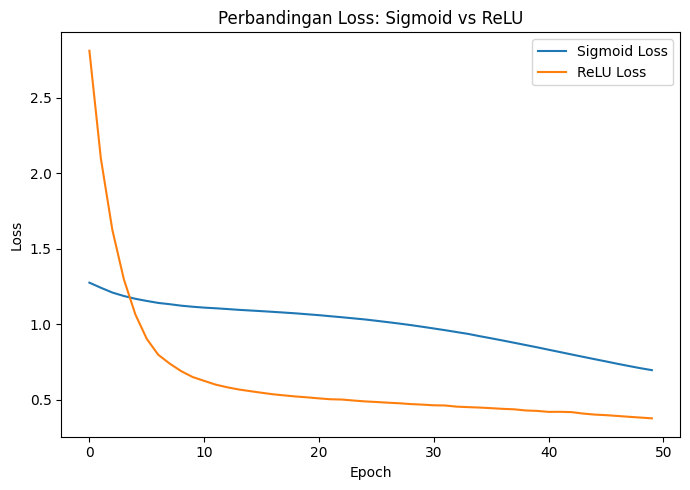

In [10]:
# Bandingkan Sigmoid vs ReLU
# Catat perbedaan loss dan akurasi

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
import numpy as np

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fungsi untuk melatih model dgn aktivasi tertentu
def run_model(activation):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(10, activation=activation, input_shape=(4,)),
        tf.keras.layers.Dense(8, activation=activation),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=50, batch_size=8, verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    return history, loss, acc

# Jalankan kedua model
history_sig, loss_sig, acc_sig = run_model("sigmoid")
history_relu, loss_relu, acc_relu = run_model("relu")

# Print hasil
print("=== HASIL PERBANDINGAN ===")
print(f"Sigmoid -> Loss: {loss_sig:.4f}, Akurasi: {acc_sig:.4f}")
print(f"ReLU    -> Loss: {loss_relu:.4f}, Akurasi: {acc_relu:.4f}")

# Visualisasi loss
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history_sig.history["loss"], label="Sigmoid Loss")
plt.plot(history_relu.history["loss"], label="ReLU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perbandingan Loss: Sigmoid vs ReLU")
plt.legend()
plt.tight_layout()
plt.show()

# PRAKTIKUM 3

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# Contoh dataset (buat dummy data)
data = pd.DataFrame({
    'luas': [50, 60, 70, 80, 90],
    'harga': [500, 600, 700, 800, 900]
})

X = data[['luas']]
y = data[['harga']]

# Normalisasi
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100)

# Evaluasi
print("Prediksi:", model.predict(X_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 945ms/step - loss: 0.8522
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.8429
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.8336
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.8244
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.8153
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.8062
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.7972
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.7882
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.7792
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.7704
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.7616
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.7528
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.7441
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.7355
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.7269
Epoch 16/100
1/1 